In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Подготовка данных

In [4]:
data = pd.read_csv("../data/creditcard.csv")

In [12]:
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)
scaler = RobustScaler()
minmax = MinMaxScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])
X_train['Time'] = minmax.fit_transform(X_train[['Time']])
X_test['Time'] = minmax.transform(X_test[['Time']])

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.2, stratify=y_train)

In [10]:
len(X_train), len(X_val), len(X_test)

(182276, 45569, 56962)

# Логистическая регрессия

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     45490
       fraud       0.88      0.63      0.74        79

    accuracy                           1.00     45569
   macro avg       0.94      0.82      0.87     45569
weighted avg       1.00      1.00      1.00     45569



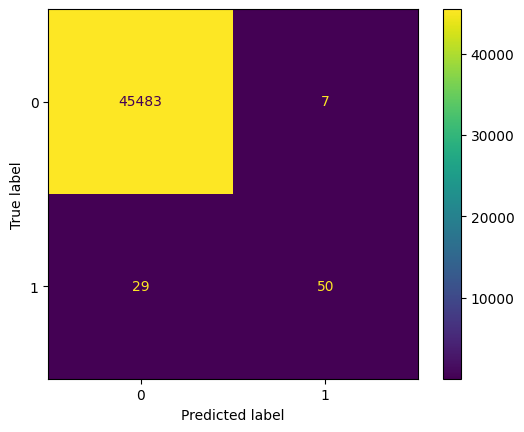

In [15]:
model = LogisticRegression()
model.fit(X_train, y_train)
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

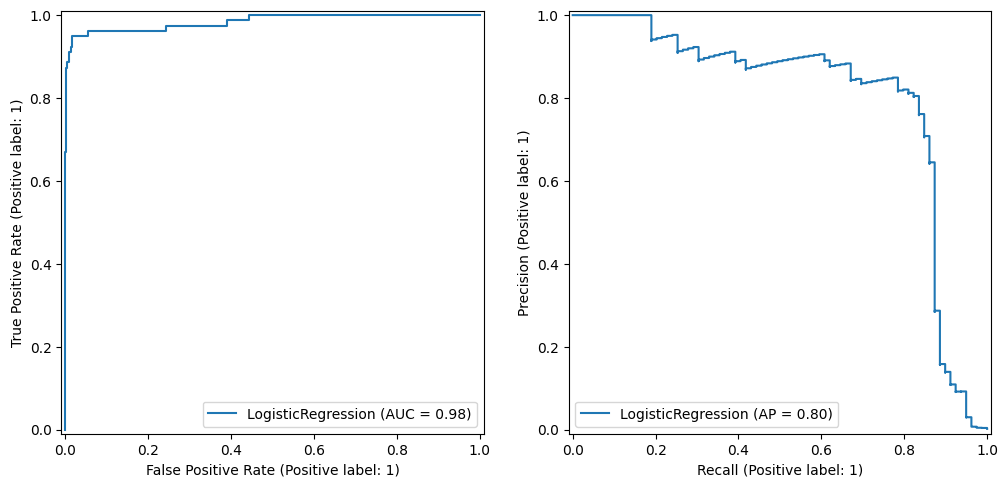

In [16]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax[0])
PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=ax[1])

### Базовая модель ожидаемо переобучилась на мажорантном классе, и пропускает очень много fraud классов

Дерево решений

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     45490
       fraud       0.90      0.82      0.86        79

    accuracy                           1.00     45569
   macro avg       0.95      0.91      0.93     45569
weighted avg       1.00      1.00      1.00     45569



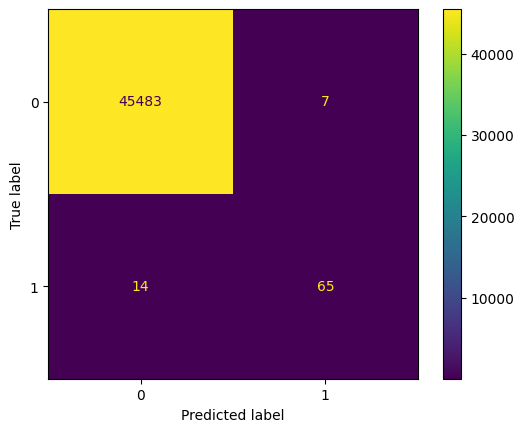

In [17]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

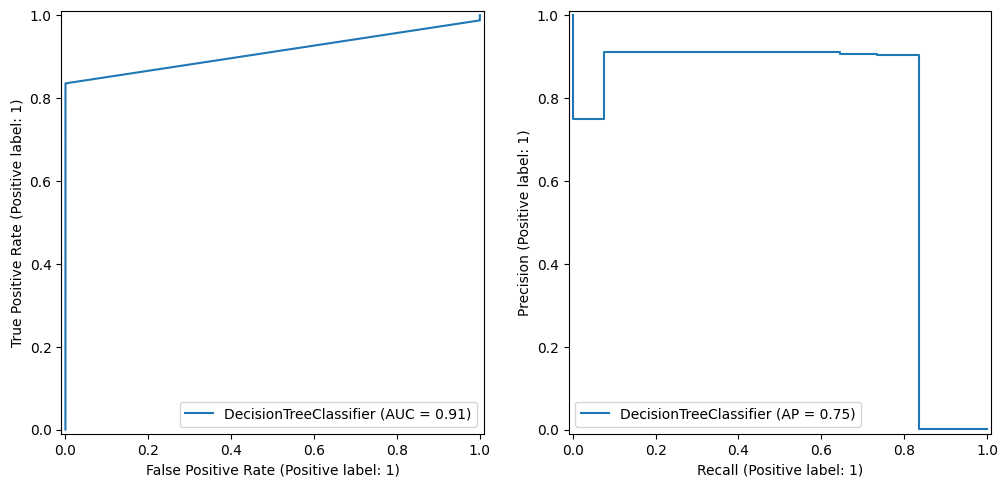

In [18]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax[0])
PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=ax[1])

### Дерево решений с ограничением на глубину имеет более высокий recall.

In [19]:
with open("../models/baseline.pkl", "wb") as f:
    pickle.dump(model, f)

# Заключение

- дерево решений с ограничением на глубину показало неплохой recall и f1. 
- датасет необычный, и требует необычных подходов к работе с данными
- для получения лучших результатов стоит попробовать андерсэмплинг (tomek links, nearmiss3)
- однозначно не стоит использовать smote (fraud класс слишком малочисленен, оверсемплинг только добавит ненужного шума)